In [1]:
!pip install -q librosa torch_geometric

import torch
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.7 MB/s eta 0:00:00
Torch: 2.11.0+cu128 | CUDA available: True


In [2]:
import os, pandas as pd, ast

if not os.path.exists('fma_metadata'):
    !wget -q https://os.unil.cloud.switch.ch/fma/fma_metadata.zip
    !unzip -q fma_metadata.zip
    print("Metadata downloaded.")

tracks = pd.read_csv('fma_metadata/tracks.csv', index_col=0, header=[0, 1])
subset = tracks[tracks['set', 'subset'] == 'small'].copy()
subset = subset.dropna(subset=[('track', 'genre_top')])
print(f"Tracks with a top genre label: {len(subset)}")

Metadata downloaded.
Tracks with a top genre label: 8000


In [3]:
N_TRACKS = 2000

sampled = (
    subset.groupby(('track', 'genre_top'), group_keys=False)
    .apply(lambda x: x.sample(min(len(x), N_TRACKS // 8), random_state=42))
)
print(f"Sampled tracks: {len(sampled)}")
print(sampled['track', 'genre_top'].value_counts())

genre_list = sorted(sampled['track', 'genre_top'].unique())
genre_to_idx = {g: i for i, g in enumerate(genre_list)}
print(genre_to_idx)

Sampled tracks: 2000
(track, genre_top)
Electronic       250
Experimental     250
Folk             250
Hip-Hop          250
Instrumental     250
International    250
Pop              250
Rock             250
Name: count, dtype: int64
{'Electronic': 0, 'Experimental': 1, 'Folk': 2, 'Hip-Hop': 3, 'Instrumental': 4, 'International': 5, 'Pop': 6, 'Rock': 7}


/tmp/ipykernel_450/3078572370.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), N_TRACKS // 8), random_state=42))


In [4]:
if not os.path.exists('fma_small.zip'):
    !wget -q --show-progress https://os.unil.cloud.switch.ch/fma/fma_small.zip
    print("Download complete.")
else:
    print("fma_small.zip already present.")

fma_small.zip       100%[===================>]   7.15G  23.2MB/s    in 5m 19s  
Download complete.


In [5]:
import zipfile

def track_id_to_path(track_id):
    tid_str = f"{track_id:06d}"
    return f"fma_small/{tid_str[:3]}/{tid_str}.mp3"

sampled_ids = sampled.index.tolist()
wanted_paths = {track_id_to_path(tid) for tid in sampled_ids}

os.makedirs('audio_subset', exist_ok=True)
extracted, missing = 0, 0

with zipfile.ZipFile('fma_small.zip', 'r') as z:
    all_names = set(z.namelist())
    for tid in sampled_ids:
        p = track_id_to_path(tid)
        if p in all_names:
            z.extract(p, 'audio_subset')
            extracted += 1
        else:
            missing += 1

print(f"Extracted: {extracted} | Missing (corrupt/skip in FMA): {missing}")

# Free up disk space — we don't need the huge zip anymore
os.remove('fma_small.zip')

Extracted: 2000 | Missing (corrupt/skip in FMA): 0


In [6]:
import librosa
import numpy as np
import torch
from torch_geometric.data import Data

SR = 22050
SEGMENT_SEC = 5
TAU = 0.85

def build_segment_graph(mp3_path, genre_idx):
    y, sr = librosa.load(mp3_path, sr=SR, duration=30)
    if len(y) < SR:
        return None

    seg_len = SEGMENT_SEC * SR
    n_segments = max(1, len(y) // seg_len)

    node_feats = []
    for i in range(n_segments):
        chunk = y[i * seg_len : (i + 1) * seg_len]
        if len(chunk) < seg_len // 2:
            continue
        # Skip near-silent segments (fixes the "empty frequency set" warning)
        if np.abs(chunk).mean() < 1e-4:
            continue

        chroma = librosa.feature.chroma_stft(y=chunk, sr=sr).mean(axis=1)   # 12-dim
        mfcc = librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=20).mean(axis=1)  # 20-dim
        combined = np.concatenate([chroma, mfcc])  # 32-dim
        node_feats.append(combined)

    if len(node_feats) < 2:
        return None

    x = torch.tensor(np.stack(node_feats), dtype=torch.float32)
    n = x.shape[0]

    edges = set()
    for i in range(n - 1):
        edges.add((i, i + 1))
        edges.add((i + 1, i))

    norm_x = x / (x.norm(dim=1, keepdim=True) + 1e-8)
    sim = norm_x @ norm_x.T
    for i in range(n):
        for j in range(n):
            if i != j and sim[i, j] > TAU:
                edges.add((i, j))

    edge_index = torch.tensor(list(edges), dtype=torch.long).T if edges else torch.empty((2, 0), dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=torch.tensor([genre_idx], dtype=torch.long))

In [7]:
from tqdm import tqdm

graphs = []
skipped = 0

for tid in tqdm(sampled_ids):
    path = os.path.join('audio_subset', track_id_to_path(tid))
    if not os.path.exists(path):
        skipped += 1
        continue
    genre = sampled.loc[tid, ('track', 'genre_top')]
    g = build_segment_graph(path, genre_to_idx[genre])
    if g is not None:
        g.track_id = int(tid)
        graphs.append(g)
    else:
        skipped += 1

print(f"Graphs built: {len(graphs)} | Skipped (corrupt/too short): {skipped}")

  4%|▎         | 72/2000 [00:35<12:48,  2.51it/s]/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
 49%|████▉     | 983/2000 [04:34<03:53,  4.36it/s]/tmp/ipykernel_450/3962431509.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(mp3_path, sr=SR, duration=30)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 51%|█████▏    | 1025/2000 [04:45<03:31,  4.61it/s]/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 2000/2000 [08:58<00:00,  3.71it/s]

Graphs built: 1998 | Skipped (corrupt/too short): 2


In [8]:
os.makedirs('results/graph_samples', exist_ok=True)
for i, g in enumerate(graphs[:25]):
    torch.save(g, f'results/graph_samples/graph_{i}.pt')
print("Saved 25 example graphs to results/graph_samples/")

Saved 25 example graphs to results/graph_samples/


In [9]:
from torch_geometric.loader import DataLoader as GeoDataLoader
import random, json

random.seed(42)
random.shuffle(graphs)

n = len(graphs)
train_graphs = graphs[: int(0.7 * n)]
val_graphs   = graphs[int(0.7 * n): int(0.85 * n)]
test_graphs  = graphs[int(0.85 * n):]

print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

train_loader = GeoDataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = GeoDataLoader(val_graphs, batch_size=32)
test_loader  = GeoDataLoader(test_graphs, batch_size=32)

split_ids = {
    "train": [int(g.track_id) for g in train_graphs],
    "val":   [int(g.track_id) for g in val_graphs],
    "test":  [int(g.track_id) for g in test_graphs],
}
with open("task2_split_track_ids.json", "w") as f:
    json.dump(split_ids, f)
print("Saved task2_split_track_ids.json")

Train: 1398 | Val: 300 | Test: 300
Saved task2_split_track_ids.json


In [10]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool

class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_dim=32, hidden_dim=64, num_classes=8, num_layers=3, dropout=0.3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_dim, hidden_dim))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
            x = self.dropout(x)
        g = global_mean_pool(x, batch)
        return self.classifier(g)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gnn_model = GraphSAGEClassifier(num_classes=len(genre_list)).to(device)
print(device)

cuda


In [11]:
from sklearn.metrics import f1_score, accuracy_score
from torch.optim import Adam

optimizer = Adam(gnn_model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

def evaluate_gnn(loader):
    gnn_model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = gnn_model(batch.x, batch.edge_index, batch.batch)
            pred = out.argmax(dim=1)
            preds.append(pred.cpu())
            labels.append(batch.y.cpu())
    preds = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    return accuracy_score(labels, preds), f1_score(labels, preds, average='macro', zero_division=0)

EPOCHS = 30
gnn_history = {'train_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(EPOCHS):
    gnn_model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = gnn_model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    val_acc, val_f1 = evaluate_gnn(val_loader)
    gnn_history['train_loss'].append(avg_loss)
    gnn_history['val_acc'].append(val_acc)
    gnn_history['val_f1'].append(val_f1)

    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")

Epoch 1/30 | Loss: 2.4757 | Val Acc: 0.2500 | Val Macro-F1: 0.2311
Epoch 3/30 | Loss: 1.8457 | Val Acc: 0.3000 | Val Macro-F1: 0.2924
Epoch 6/30 | Loss: 1.7318 | Val Acc: 0.3433 | Val Macro-F1: 0.3236
Epoch 9/30 | Loss: 1.6580 | Val Acc: 0.3800 | Val Macro-F1: 0.3731
Epoch 12/30 | Loss: 1.6234 | Val Acc: 0.3433 | Val Macro-F1: 0.3309
Epoch 15/30 | Loss: 1.5422 | Val Acc: 0.3667 | Val Macro-F1: 0.3511
Epoch 18/30 | Loss: 1.4819 | Val Acc: 0.3500 | Val Macro-F1: 0.3437
Epoch 21/30 | Loss: 1.4564 | Val Acc: 0.3467 | Val Macro-F1: 0.3281
Epoch 24/30 | Loss: 1.3755 | Val Acc: 0.3800 | Val Macro-F1: 0.3749
Epoch 27/30 | Loss: 1.3429 | Val Acc: 0.3600 | Val Macro-F1: 0.3518
Epoch 30/30 | Loss: 1.2454 | Val Acc: 0.3767 | Val Macro-F1: 0.3646


In [12]:
test_acc, test_f1 = evaluate_gnn(test_loader)
print(f"GNN Test Accuracy: {test_acc:.4f}")
print(f"GNN Test Macro-F1: {test_f1:.4f}")

GNN Test Accuracy: 0.3733
GNN Test Macro-F1: 0.3580


In [13]:
import json

# Save trained GNN weights
torch.save(gnn_model.state_dict(), "task2_gnn_graphsage.pt")

# Save the exact config so Task 3 rebuilds compatible graphs
config = {
    "N_TRACKS": N_TRACKS,          # 2000
    "in_dim": 32,                   # chroma(12) + mfcc(20)
    "hidden_dim": 64,
    "num_layers": 3,
    "num_classes": len(genre_list),
    "genre_to_idx": genre_to_idx,
    "SEGMENT_SEC": SEGMENT_SEC,
    "TAU": TAU,
    "SR": SR,
}
with open("task2_gnn_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved task2_gnn_graphsage.pt and task2_gnn_config.json")

Saved task2_gnn_graphsage.pt and task2_gnn_config.json


In [14]:
from torch.utils.data import Dataset, DataLoader

MEL_BINS = 64
TIME_FRAMES = 130  # ~3s worth at default hop; we'll pad/crop to a fixed size

def get_mel_spec(mp3_path):
    y, sr = librosa.load(mp3_path, sr=SR, duration=10)  # shorter clip is enough for CNN baseline
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=MEL_BINS)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < TIME_FRAMES:
        pad = TIME_FRAMES - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad)))
    else:
        mel_db = mel_db[:, :TIME_FRAMES]

    return mel_db.astype(np.float32)

class MelSpecDataset(Dataset):
    def __init__(self, track_ids, labels):
        self.track_ids = track_ids
        self.labels = labels

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, idx):
        tid = self.track_ids[idx]
        path = os.path.join('audio_subset', track_id_to_path(tid))
        mel = get_mel_spec(path)
        return torch.tensor(mel).unsqueeze(0), torch.tensor(self.labels[idx], dtype=torch.long)

# Reuse the same track split as the GNN (by re-deriving ids that produced valid graphs)
valid_ids = [tid for tid in sampled_ids if os.path.exists(os.path.join('audio_subset', track_id_to_path(tid)))]
valid_labels = [genre_to_idx[sampled.loc[tid, ('track', 'genre_top')]] for tid in valid_ids]

random.seed(42)
combined = list(zip(valid_ids, valid_labels))
random.shuffle(combined)
valid_ids, valid_labels = zip(*combined)

n2 = len(valid_ids)
train_ids, train_labels = valid_ids[:int(0.7*n2)], valid_labels[:int(0.7*n2)]
val_ids, val_labels     = valid_ids[int(0.7*n2):int(0.85*n2)], valid_labels[int(0.7*n2):int(0.85*n2)]
test_ids, test_labels   = valid_ids[int(0.85*n2):], valid_labels[int(0.85*n2):]

cnn_train_loader = DataLoader(MelSpecDataset(train_ids, train_labels), batch_size=32, shuffle=True)
cnn_val_loader   = DataLoader(MelSpecDataset(val_ids, val_labels), batch_size=32)
cnn_test_loader  = DataLoader(MelSpecDataset(test_ids, test_labels), batch_size=32)

In [15]:
class MelCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.fc = nn.Linear(64 * 4 * 4, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = x.flatten(1)
        return self.fc(x)

cnn_model = MelCNN(num_classes=len(genre_list)).to(device)

In [16]:
cnn_optimizer = Adam(cnn_model.parameters(), lr=1e-3)

def evaluate_cnn(loader):
    cnn_model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = cnn_model(x)
            preds.append(out.argmax(dim=1).cpu())
            labels.append(y.cpu())
    preds = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    return accuracy_score(labels, preds), f1_score(labels, preds, average='macro', zero_division=0)

cnn_history = {'train_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(EPOCHS):
    cnn_model.train()
    total_loss = 0
    for x, y in cnn_train_loader:
        x, y = x.to(device), y.to(device)
        cnn_optimizer.zero_grad()
        out = cnn_model(x)
        loss = criterion(out, y)
        loss.backward()
        cnn_optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(cnn_train_loader)
    val_acc, val_f1 = evaluate_cnn(cnn_val_loader)
    cnn_history['train_loss'].append(avg_loss)
    cnn_history['val_acc'].append(val_acc)
    cnn_history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")

/tmp/ipykernel_450/540828164.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(mp3_path, sr=SR, duration=10)  # shorter clip is enough for CNN baseline
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Epoch 1/30 | Loss: 2.3507 | Val Acc: 0.1233 | Val Macro-F1: 0.0581


/tmp/ipykernel_450/540828164.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(mp3_path, sr=SR, duration=10)  # shorter clip is enough for CNN baseline
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Epoch 2/30 | Loss: 2.0755 | Val Acc: 0.1200 | Val Macro-F1: 0.0507


/tmp/ipykernel_450/540828164.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(mp3_path, sr=SR, duration=10)  # shorter clip is enough for CNN baseline
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


...

Epoch 28/30 | Loss: 1.0623 | Val Acc: 0.3733 | Val Macro-F1: 0.3662


/tmp/ipykernel_450/540828164.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(mp3_path, sr=SR, duration=10)  # shorter clip is enough for CNN baseline
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Epoch 29/30 | Loss: 1.0612 | Val Acc: 0.3833 | Val Macro-F1: 0.3859


/tmp/ipykernel_450/540828164.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(mp3_path, sr=SR, duration=10)  # shorter clip is enough for CNN baseline
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Epoch 30/30 | Loss: 0.9448 | Val Acc: 0.3800 | Val Macro-F1: 0.3786


In [17]:
cnn_test_acc, cnn_test_f1 = evaluate_cnn(cnn_test_loader)

print("=== Final Comparison (Test Set) ===")
print(f"GraphSAGE (GNN) | Accuracy: {test_acc:.4f} | Macro-F1: {test_f1:.4f}")
print(f"CNN (mel-spec)  | Accuracy: {cnn_test_acc:.4f} | Macro-F1: {cnn_test_f1:.4f}")

=== Final Comparison (Test Set) ===
GraphSAGE (GNN) | Accuracy: 0.3733 | Macro-F1: 0.3580
CNN (mel-spec)  | Accuracy: 0.3500 | Macro-F1: 0.3527


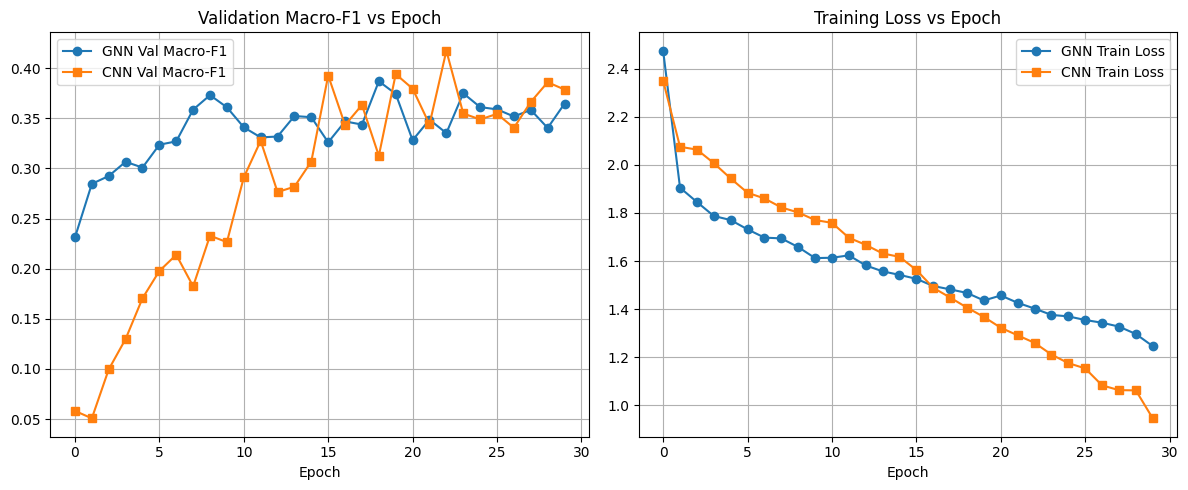

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(gnn_history['val_f1'], label='GNN Val Macro-F1', marker='o')
axes[0].plot(cnn_history['val_f1'], label='CNN Val Macro-F1', marker='s')
axes[0].set_title('Validation Macro-F1 vs Epoch')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(gnn_history['train_loss'], label='GNN Train Loss', marker='o')
axes[1].plot(cnn_history['train_loss'], label='CNN Train Loss', marker='s')
axes[1].set_title('Training Loss vs Epoch')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

Found 25 graph files



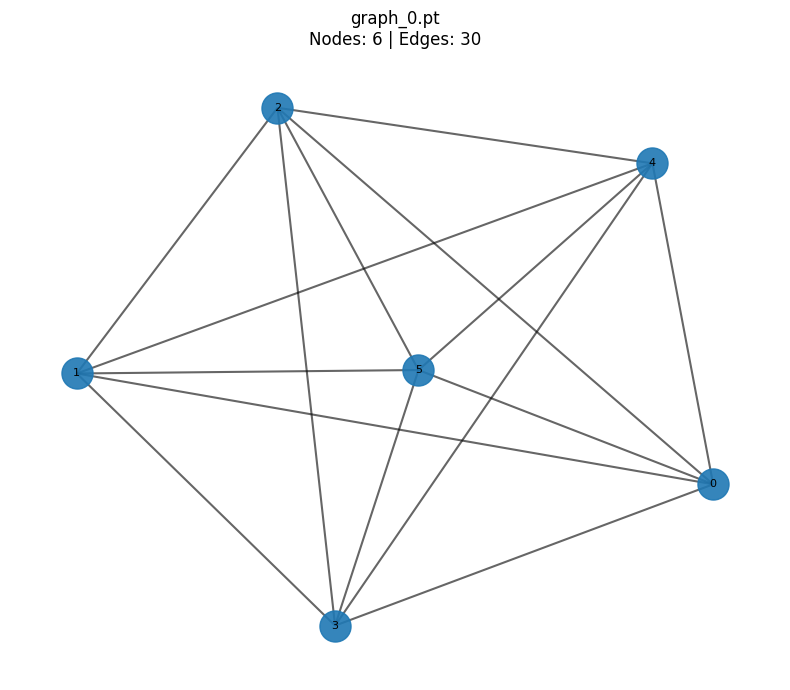

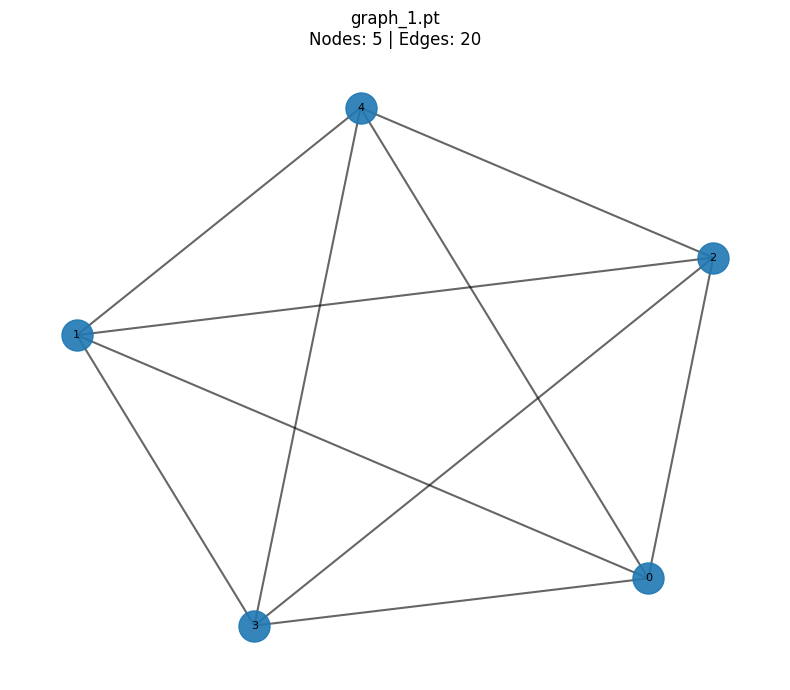

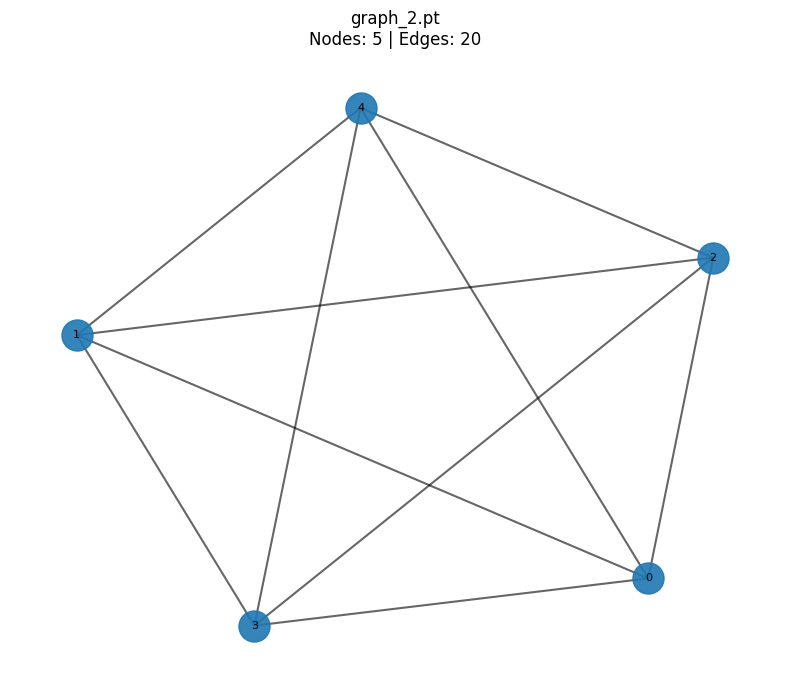

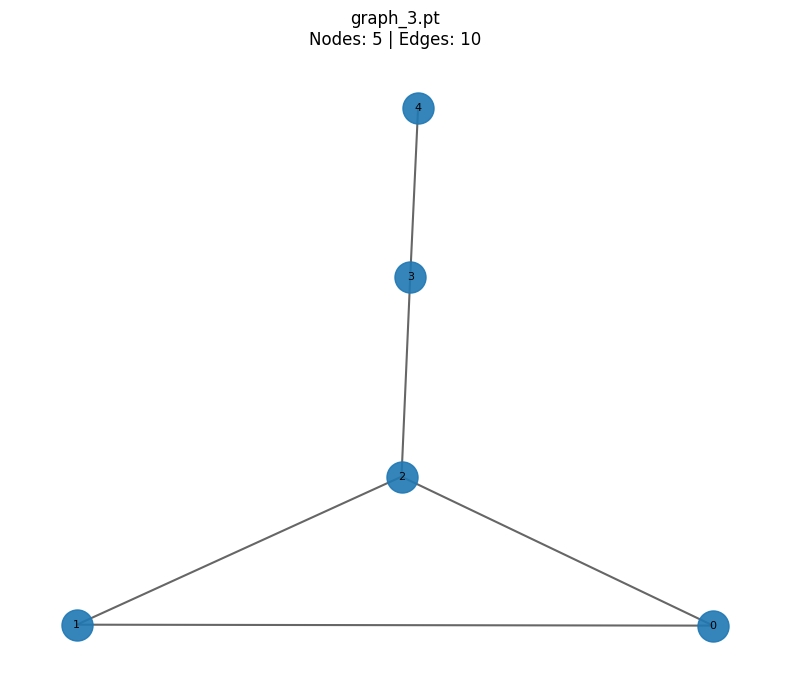

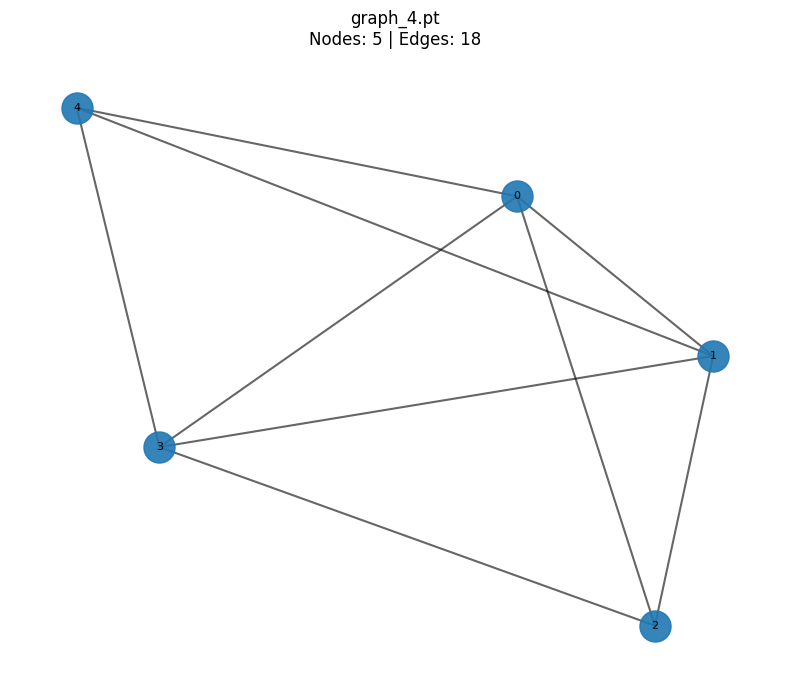

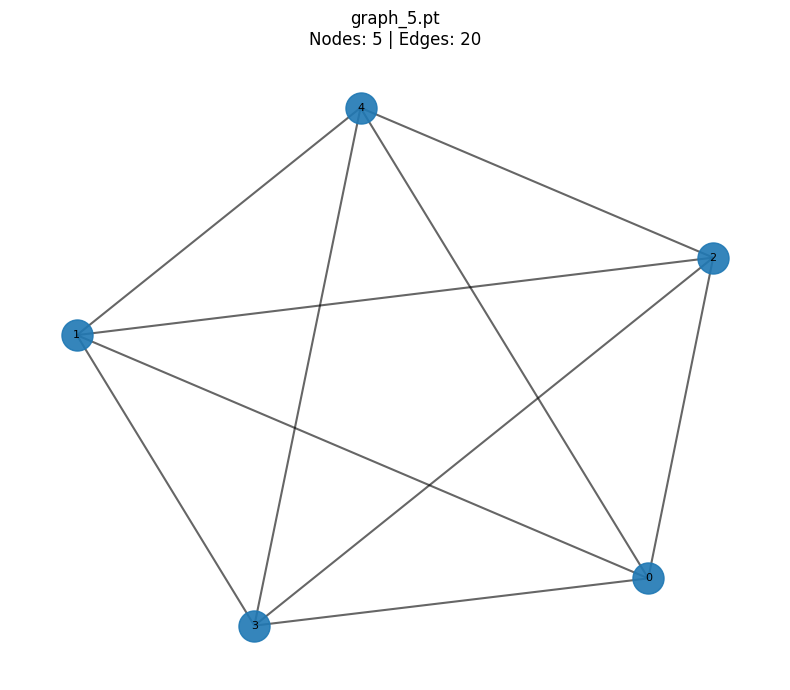

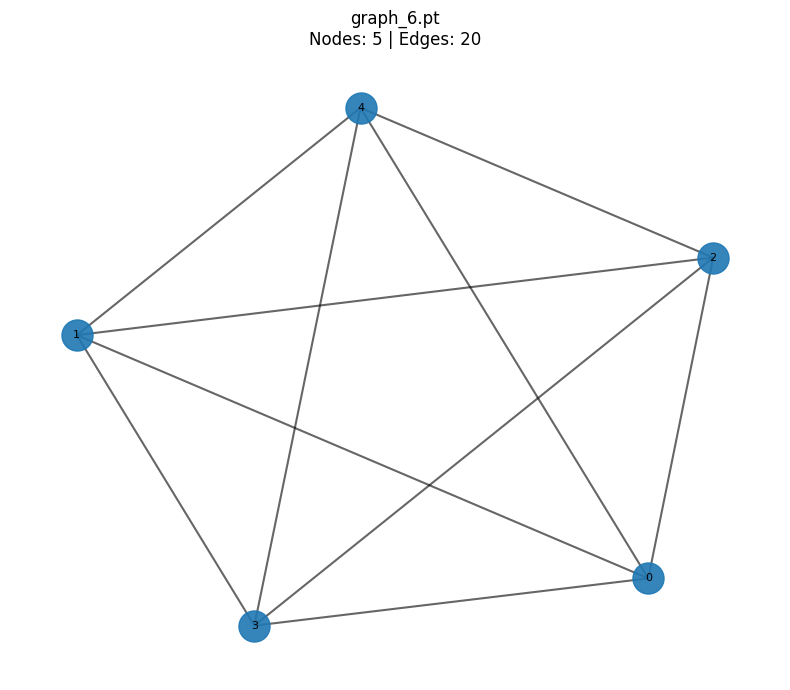

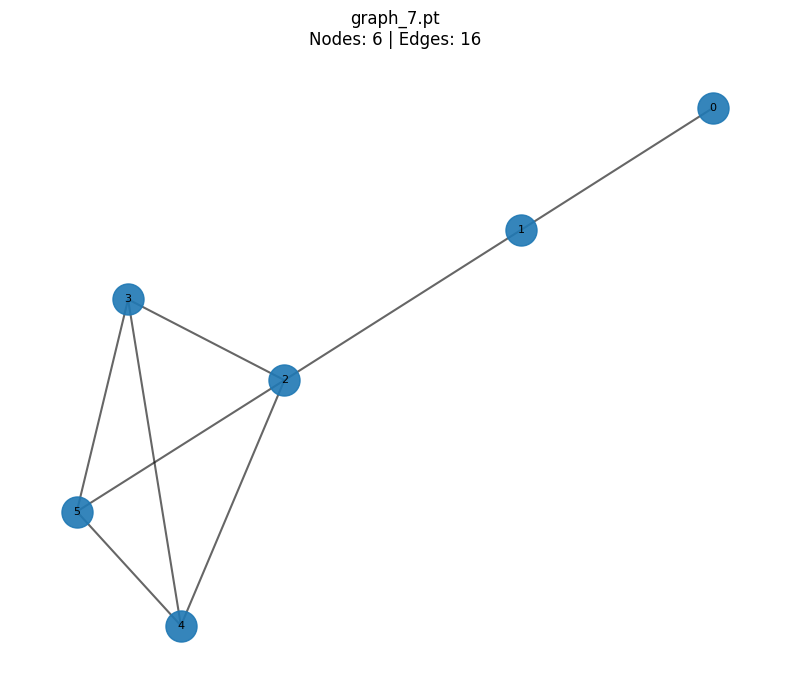

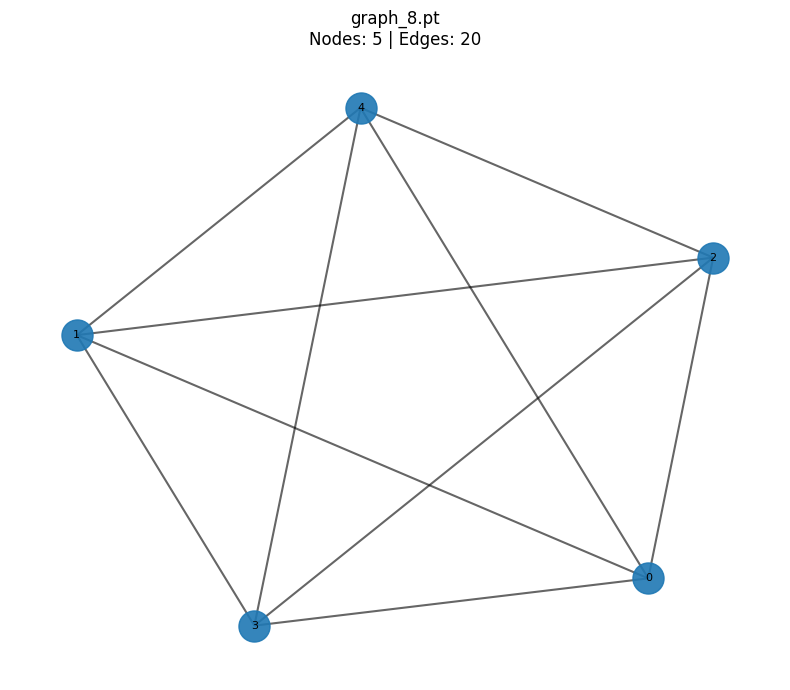

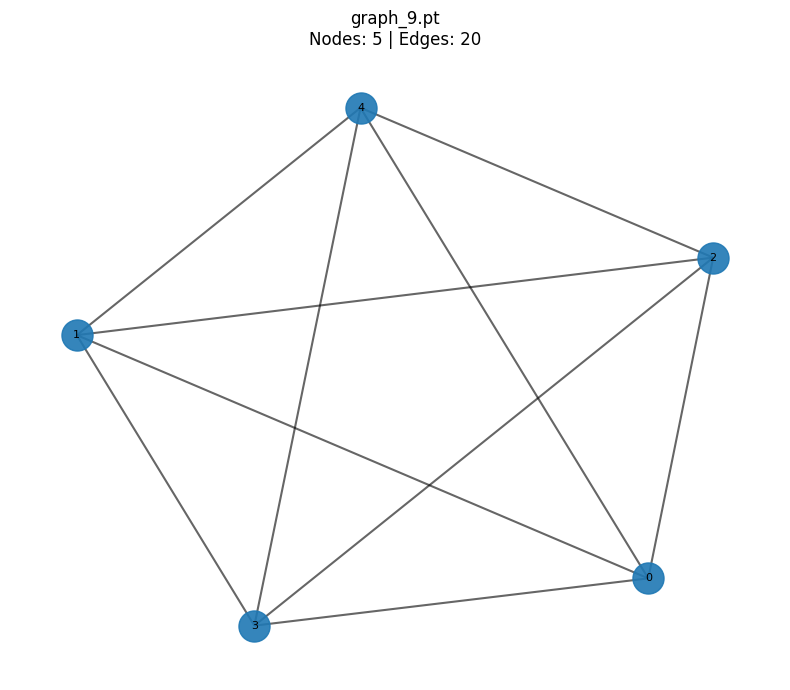

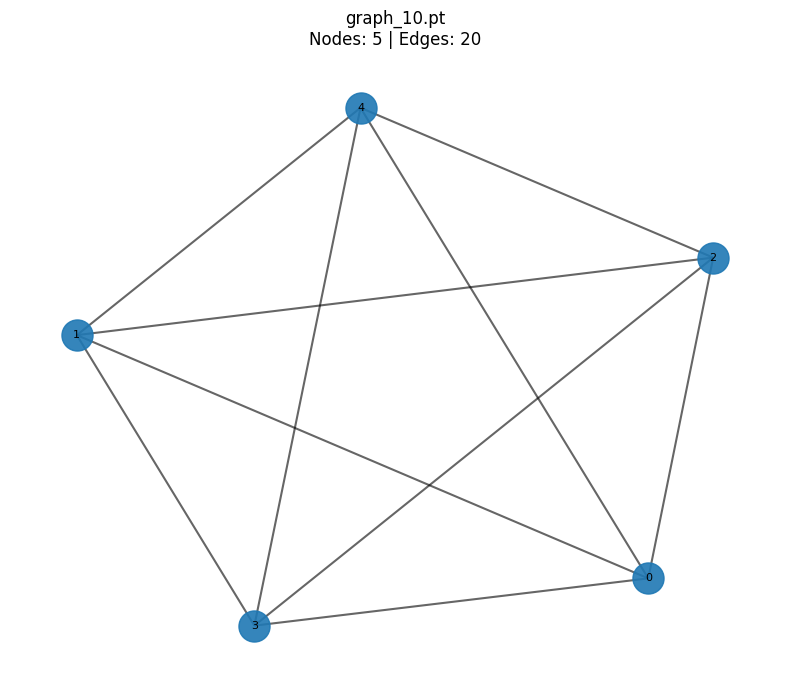

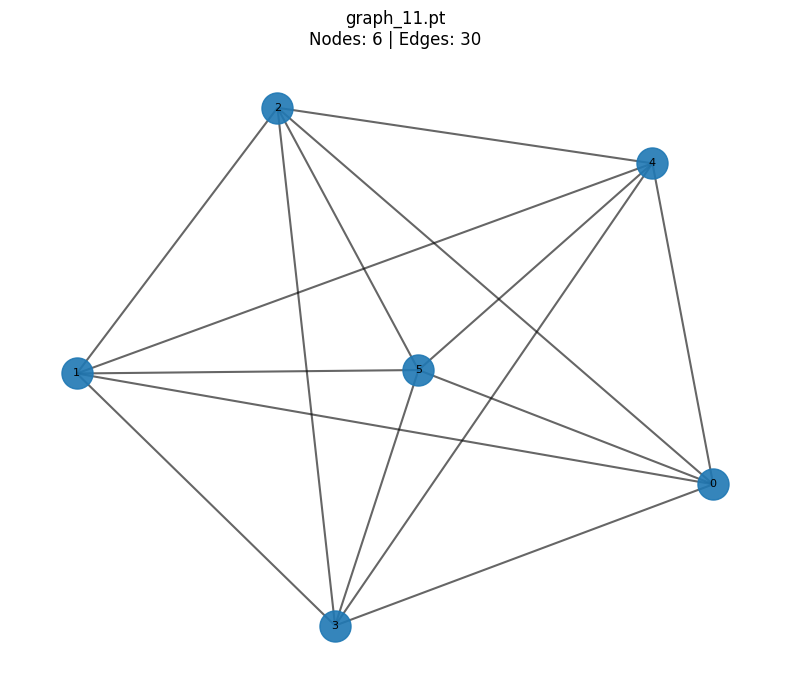

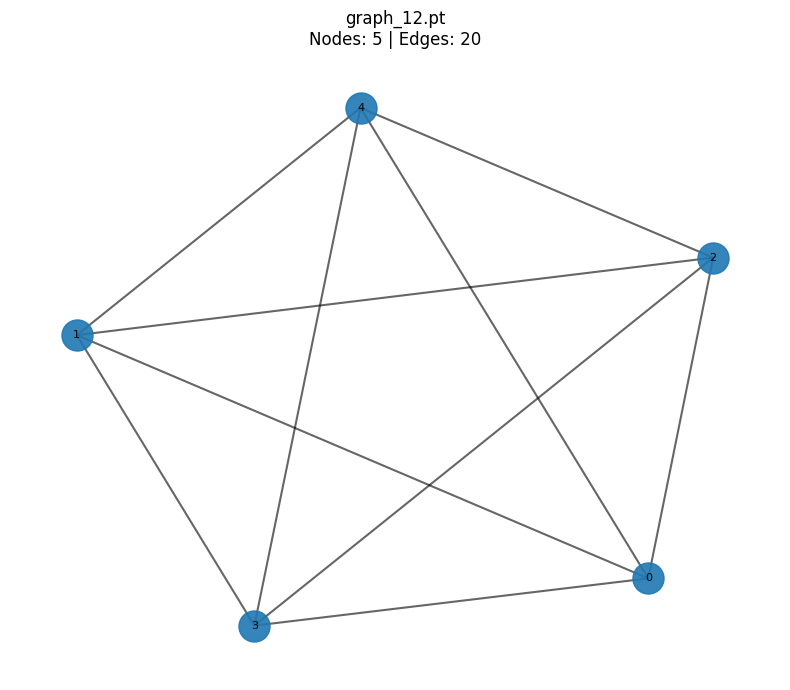

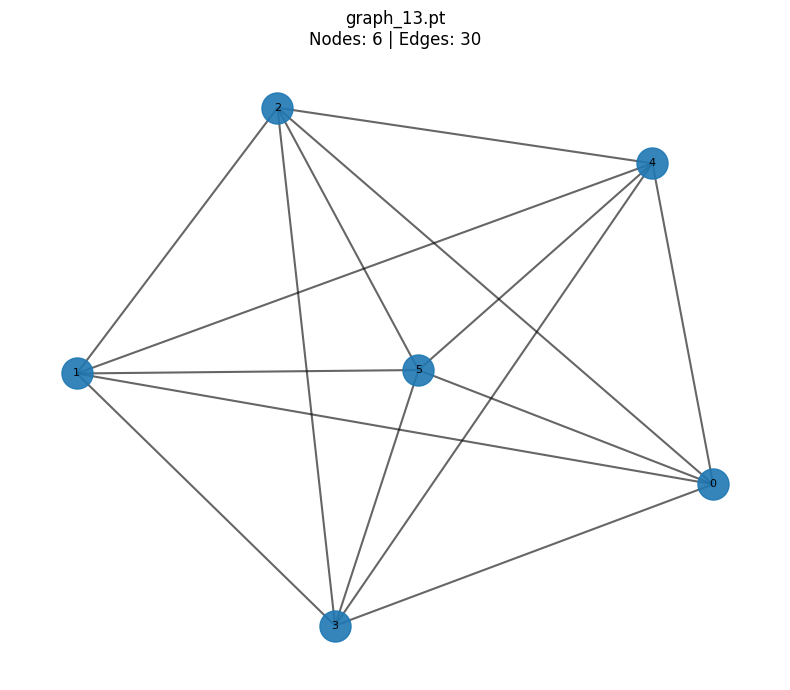

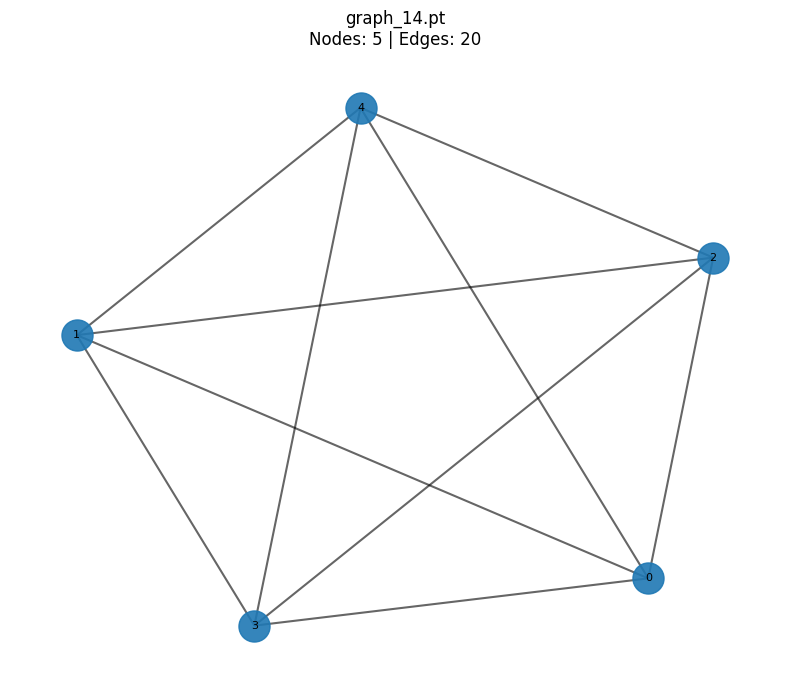

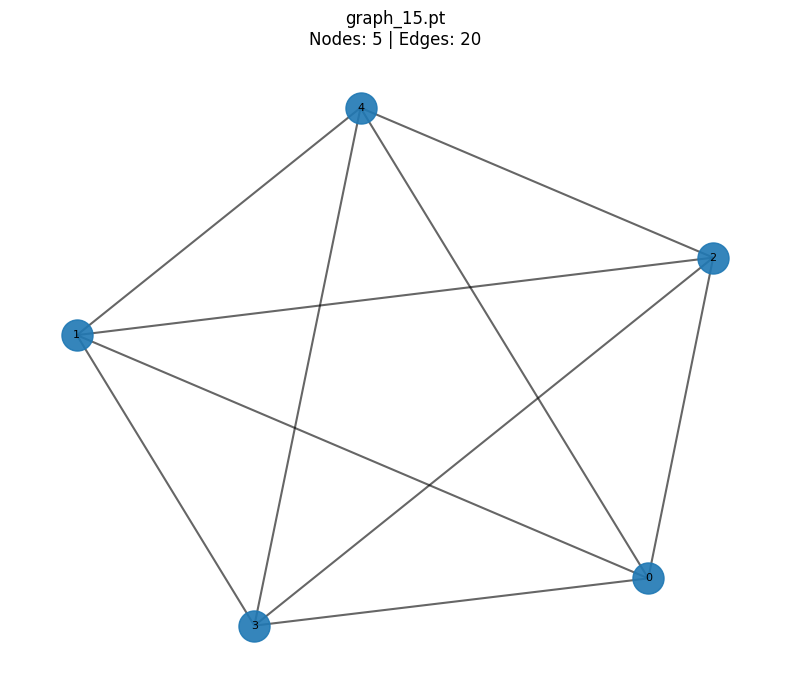

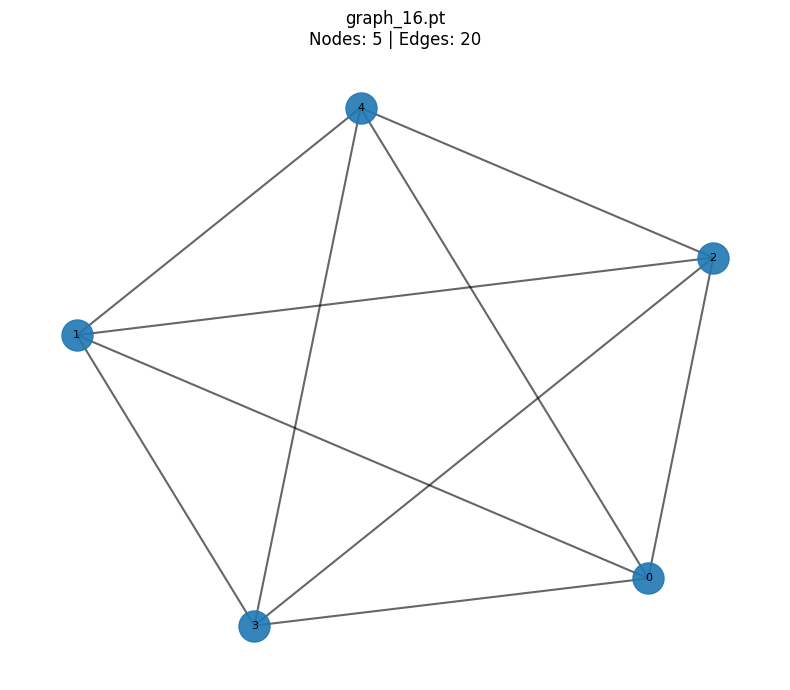

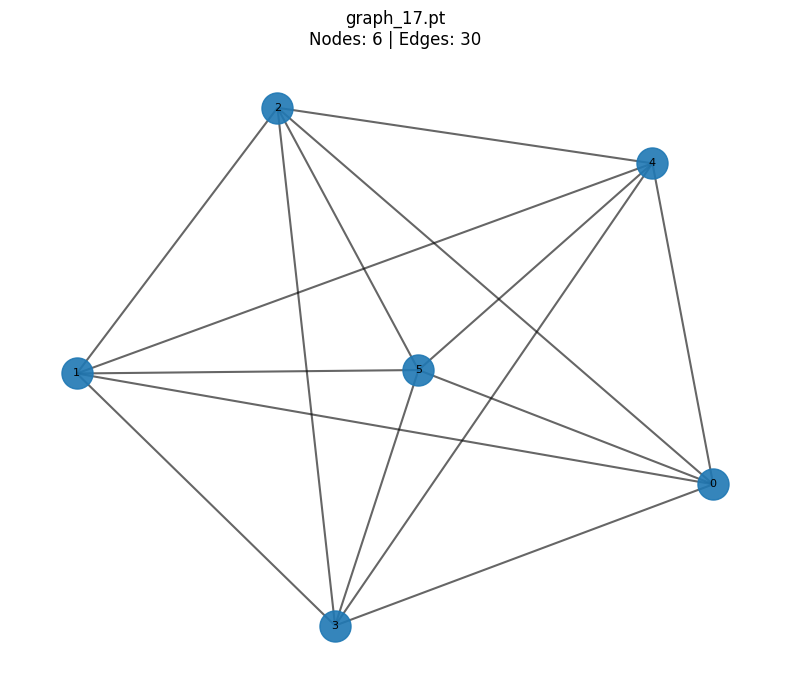

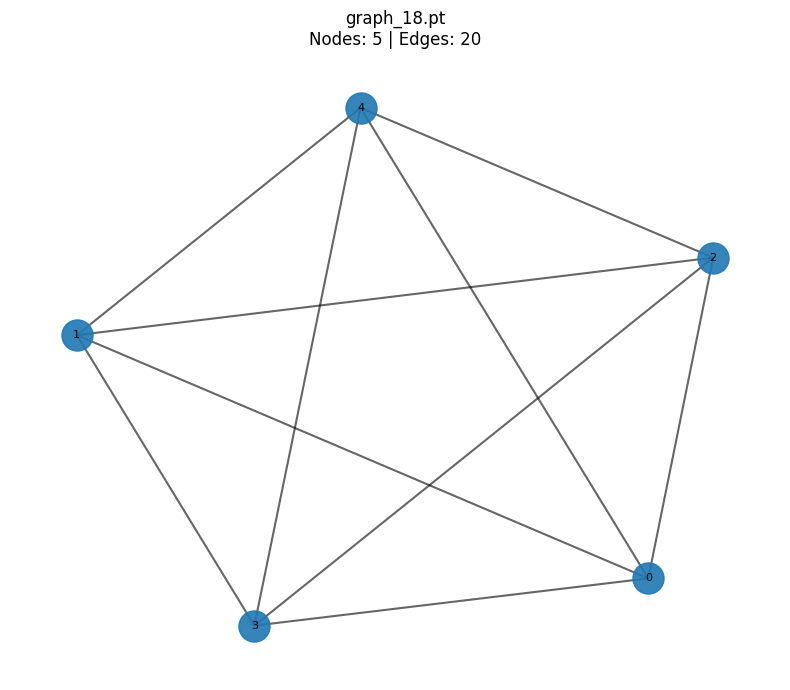

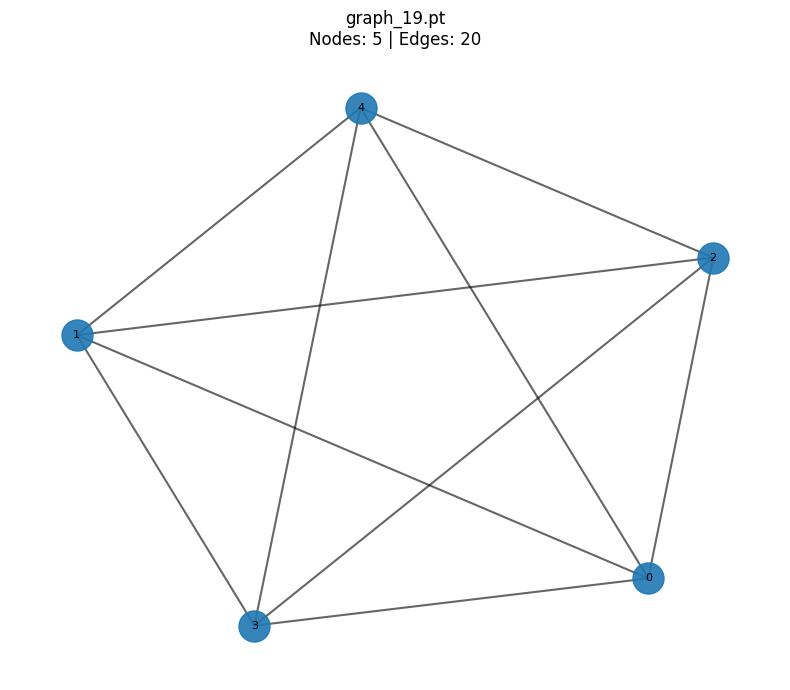

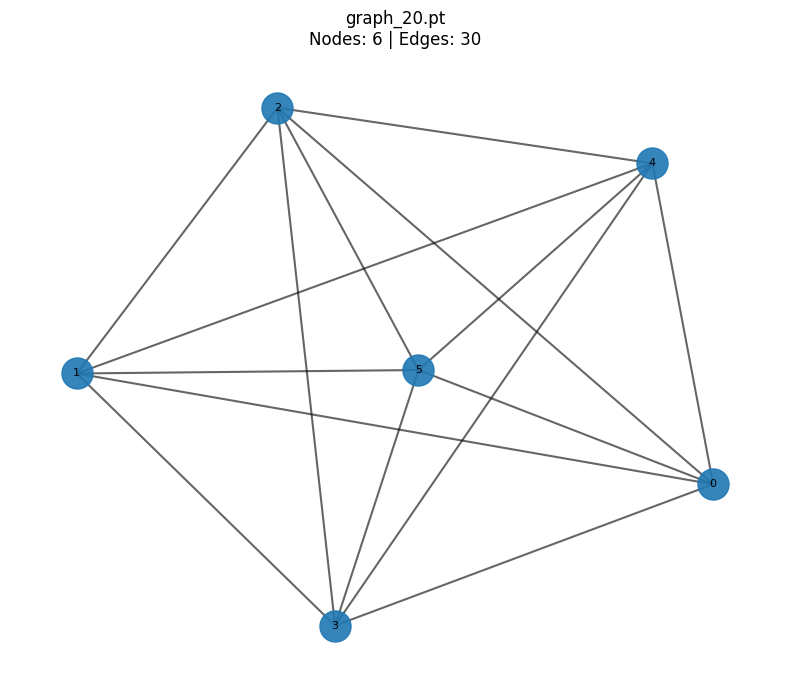

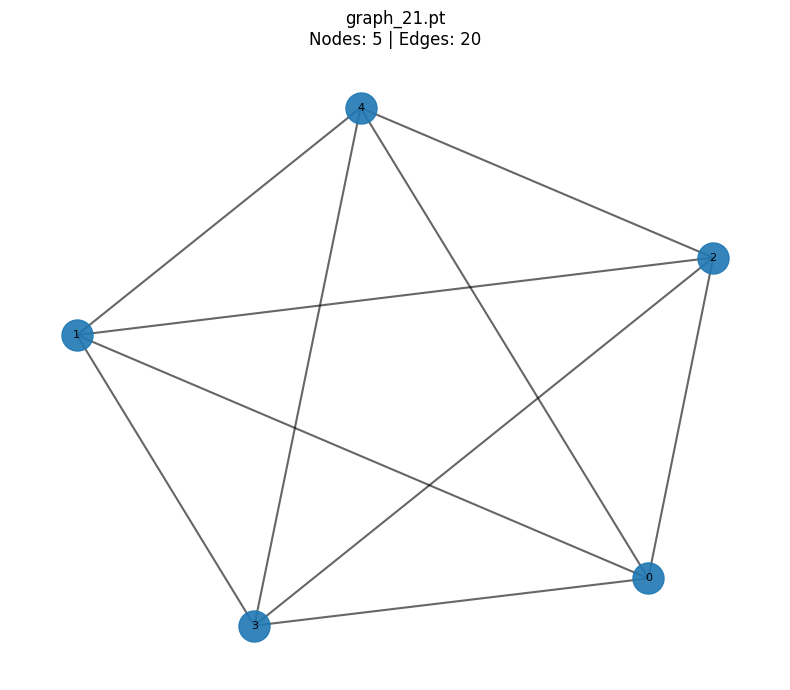

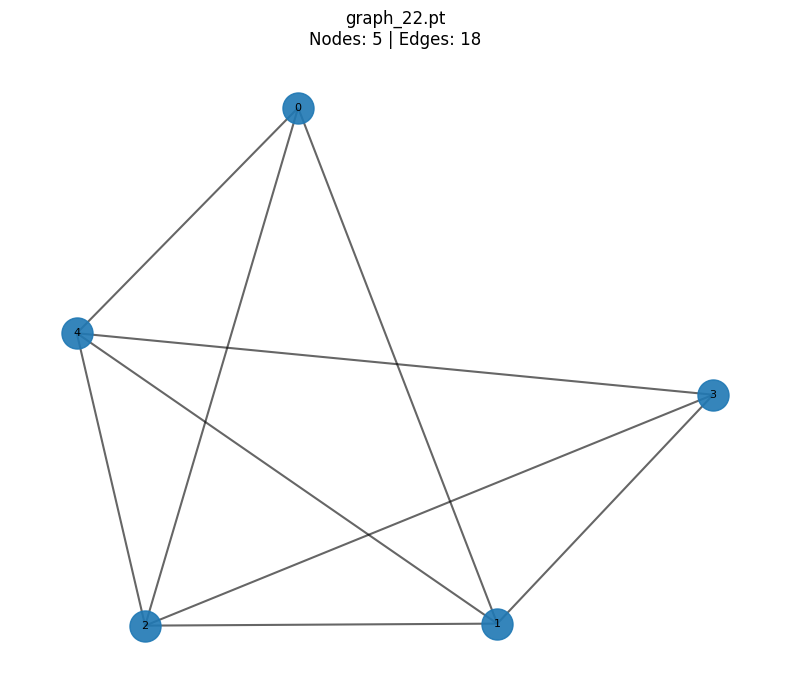

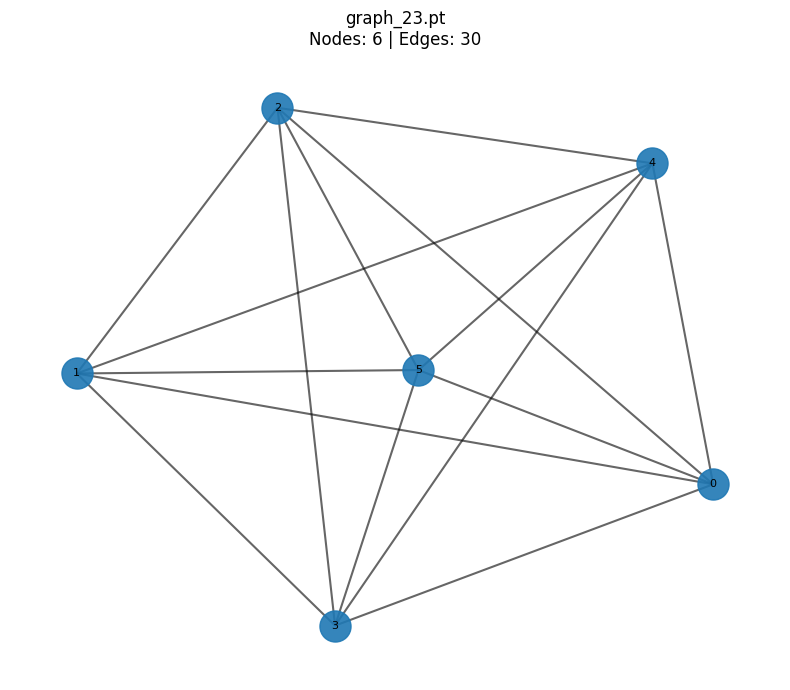

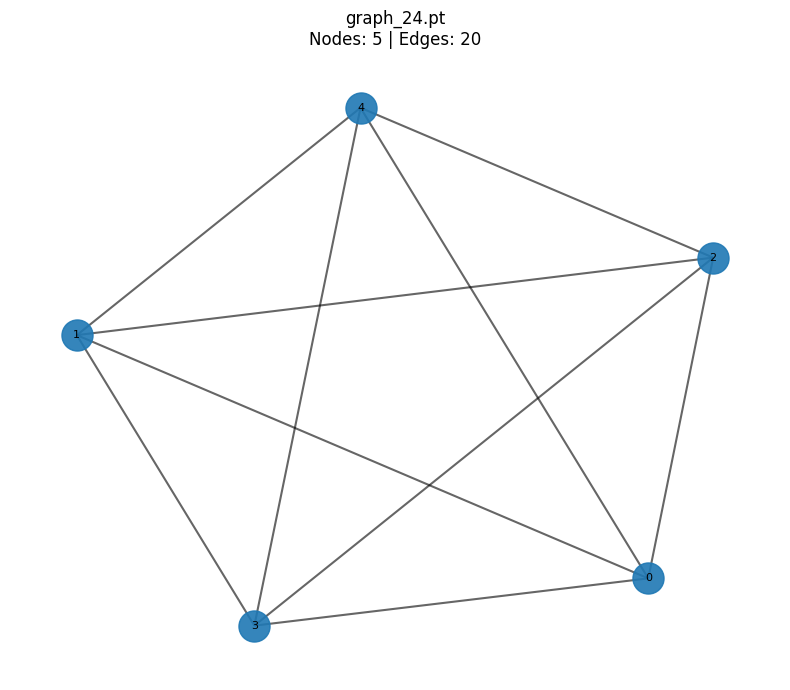

In [19]:
# Visualize all .pt graph files

import os
import glob
import torch
import matplotlib.pyplot as plt
import networkx as nx

GRAPH_DIR = "/content/results/graph_samples"

graph_files = sorted(
    glob.glob(os.path.join(GRAPH_DIR, "graph_*.pt")),
    key=lambda x: int(os.path.basename(x).split("_")[1].split(".")[0])
)

print(f"Found {len(graph_files)} graph files\n")

for file_path in graph_files:

    # Load graph
    graph = torch.load(file_path, weights_only=False)

    if hasattr(graph, "to_networkx"):
        G = graph.to_networkx()
    else:
        edge_index = graph["edge_index"]
        G = nx.Graph()
        G.add_edges_from(edge_index.t().tolist())

    # Basic information
    num_nodes = graph.num_nodes if hasattr(graph, "num_nodes") else G.number_of_nodes()
    num_edges = graph.num_edges if hasattr(graph, "num_edges") else G.number_of_edges()

    # Draw
    plt.figure(figsize=(8, 7))

    pos = nx.spring_layout(
        G,
        seed=42,
        k=1.5 / max(num_nodes ** 0.5, 1)
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=500,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G,
        pos,
        width=1.5,
        alpha=0.6
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=8
    )

    plt.title(
        f"{os.path.basename(file_path)}\n"
        f"Nodes: {num_nodes} | Edges: {num_edges}"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()